## _Building Graphs: True Edges_

In [1]:
import glob, os, sys, yaml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
import seaborn as sns
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data
import itertools

In [5]:
# append parent dir
sys.path.append('..')

# local imports
from src import Compose_Event, Draw_Compose_Event

### _(+) - Input Data_

In [6]:
# input data
input_dir = '../train_all'

In [7]:
# Find All Input Data Files (hits.csv, cells.csv, particles.csv, truth.csv)
all_files = os.listdir(input_dir)

# Extract File Prefixes (use e.g. xxx-hits.csv)
suffix = '-hits.csv'
file_prefixes = sorted(os.path.join(input_dir, f.replace(suffix, ''))
                       for f in all_files if f.endswith(suffix))

In [8]:
# file_prefixes[:10]

In [9]:
event_id = 0
event_prefix = file_prefixes[event_id]

In [10]:
# load an event
hits, tubes, particles, truth = trackml.dataset.load_event(event_prefix)

# memory usage
mem_bytes = (hits.memory_usage(index=True).sum() 
             + tubes.memory_usage(index=True).sum() 
             + particles.memory_usage(index=True).sum() 
             + truth.memory_usage(index=True).sum())

print('{} memory usage {:.2f} MB'.format(os.path.basename(event_prefix), mem_bytes / 2**20))

event0000000000 memory usage 0.03 MB


In [11]:
hits.head()

,hit_id,x,y,z,volume_id,layer_id,module_id
0,1,-4.57218,1.089970,14.780000,2,13,367
1,2,-2.13939,0.663788,6.980000,2,11,344
2,3,1.89899,4.346520,-3.207740,2,6,23
3,4,2.11633,0.776864,-0.780989,2,1,26
4,5,2.30500,-4.161470,6.980000,2,7,281


In [12]:
tubes.head()

,hit_id,depcharge,energyloss,volume_id,layer_id,module_id,sector_id,isochrone,skewed
0,1,17203.7,0.000062,2,13,367,NaN,NaN,NaN
1,2,15239.6,0.000055,2,11,344,NaN,NaN,NaN
2,3,16798.7,0.000061,2,6,23,NaN,NaN,NaN
3,4,16696.1,0.000060,2,1,26,NaN,NaN,NaN
4,5,18984.3,0.000069,2,7,281,NaN,NaN,NaN


In [13]:
particles.head()

,particle_id,vx,vy,vz,px,py,pz,q,nhits,pdgcode,start_time,primary
0,1,0.0,0.0,0.0,0.404798,0.910754,-0.521365,1,27,13,0.0,1
1,2,0.0,0.0,0.0,-0.333047,-0.237710,0.841370,1,30,13,0.0,1
2,3,0.0,0.0,0.0,-0.091231,0.032307,0.303326,1,37,13,0.0,1
3,4,0.0,0.0,0.0,0.529088,0.202146,-0.480807,1,28,13,0.0,1
4,5,0.0,0.0,0.0,-0.192276,0.331225,0.860149,1,29,13,0.0,1


In [14]:
truth.head()

,hit_id,tx,ty,tz,tpx,tpy,tpz,weight,particle_id
0,1,-4.56836,1.089560,14.770000,-0.092453,0.012600,0.299778,1.0,3
1,2,-2.13620,0.660008,6.970000,-0.093832,0.024646,0.302051,1.0,3
2,3,1.89475,4.337460,-2.472890,0.392931,0.916020,-0.520551,1.0,1
3,4,2.10656,0.774229,-0.777399,1.294080,0.472316,-0.476282,1.0,6
4,5,2.30153,-4.156090,6.970000,0.378069,-0.699892,1.166880,1.0,7


I am running


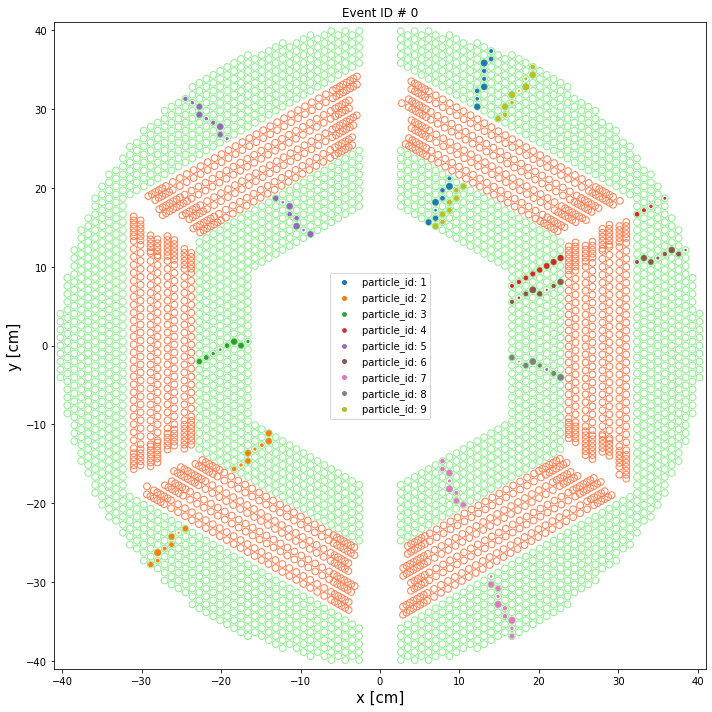

In [15]:
event = Compose_Event(event_prefix,skewed=False)
Draw_Compose_Event(event,figsize=(10,10));

### _(+) - Build Event_

- functions from _event_utils.py_

In [16]:
def get_vlids(hits):
    """Get list of  tuple=(volume_id, layer_id) from Hits"""
    # Get a list of unique and sorted tuple=(volume_id, layer_id)
    vlids = hits[['volume_id', 'layer_id']].drop_duplicates()
    vlids = vlids.sort_values(['volume_id', 'layer_id'], ascending=[True, True])
    vlids = list(zip(vlids.volume_id, vlids.layer_id))
    return vlids


def select_hits(event_prefix=None, skewed=False, noise=False, min_pt=None):
    """Hit selection, merge info into a single dataframe"""
    
    hits, tubes, particles, truth = trackml.dataset.load_event(event_prefix)
    
    # Drop duplicates (present due to "PndMLTracker")
    particles['nhits'] = particles.groupby(['particle_id'])['nhits'].transform('count')
    particles.drop_duplicates(inplace=True, ignore_index=True)
    
    if noise:
        truth = truth.merge(
            particles[["particle_id", "vx", "vy", "vz"]], on="particle_id", how="left"
        )
    else:
        truth = truth.merge(
            particles[["particle_id", "vx", "vy", "vz"]], on="particle_id", how="inner"
        )
    
    truth = truth.assign(pt=np.sqrt(truth.tpx**2 + truth.tpy**2))
    
    if min_pt:
        truth = truth[truth.pt > min_pt]

    # ADAK: Start
    # ------------------------------------------------------------------------------------
    
    # Need 'isochrone', 'skewed' & 'sector_id' columns from 'tubes'
    hits = hits.merge(tubes[["hit_id", "isochrone", "skewed", "sector_id"]], on="hit_id")

    # Filter Skewed Layers
    if skewed is False:
        print("im running")
        hits = hits.query('skewed!=1')
    
    vlids = get_vlids(hits)
    n_det_layers = len(vlids)
    
    # Select layers and assign convenient layer number [0...n_det_layers]
    vlid_groups = hits.groupby(["volume_id", "layer_id"])
    hits = pd.concat(
        [vlid_groups.get_group(vlids[i]).assign(layer_id=i) for i in range(n_det_layers)]
    )
    
    # ADAK: End
    # ------------------------------------------------------------------------------------
    
    # Calculate derived hits variables
    r = np.sqrt(hits.x**2 + hits.y**2)
    phi = np.arctan2(hits.y, hits.x)
    
    # Select the data columns we need
    hits = hits.assign(r=r, phi=phi).merge(truth, on="hit_id")
    
    return hits

In [17]:
hits.volume_id.unique()

array([2, 3, 6, 9], dtype=int32)

In [18]:
hits.layer_id.unique()

array([13, 11,  6,  1,  7,  5, 12, 14,  2, 17, 20, 15, 16, 23, 24, 25, 26,
       27, 28,  0,  3,  4, 18, 19, 21, 22,  9], dtype=int32)

In [19]:
hits = select_hits(event_prefix=event_prefix, skewed=False, noise=False, min_pt=None)

im running


In [20]:
hits.skewed.values

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0

In [21]:
hits.volume_id.unique()

array([2, 3, 6, 9], dtype=int32)

In [22]:
hits.layer_id.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36])

## _Build Graphs_

### _(A) - True Edges (Layerwise)_

**True Graph** is the ground truth for GNN. It is built from creating edges from _`hits`_ from the same particle but in adjacent layers. 

For this purpose one has _`true_edges, hits = get_layerwise_edges(event)`_ function in the _`event_util.py`_.

In [23]:
# true_edges, hits = get_layerwise_edges(event)

In [24]:
# EDA on get_layerwise_edges(event)

In [25]:
hits = hits.assign(
        R=np.sqrt(
            (hits.x - hits.vx) ** 2 + (hits.y - hits.vy) ** 2 + (hits.z - hits.vz) ** 2
        )
    )

In [26]:
hits = hits.sort_values("R").reset_index(drop=True).reset_index(drop=False)

In [27]:
hits.loc[hits["particle_id"] == 0, "particle_id"] = np.nan

In [28]:
hit_list = (
        hits.groupby(["particle_id", "layer_id"], sort=False)["index"]
        .agg(lambda x: list(x))
        .groupby(level=0)
        .agg(lambda x: list(x))
    )

In [29]:
hit_list

particle_id
1.0    [[7], [15, 17], [22, 23], [34, 104], [45], [52...
2.0    [[5], [12], [18], [29, 32], [53], [60], [71], ...
3.0    [[4], [10], [16], [24, 25], [33], [40], [46], ...
4.0    [[2], [9], [19], [26], [39, 112], [54], [64], ...
5.0    [[3], [11], [31], [41], [50], [57], [65], [73]...
6.0    [[0], [6], [14], [21], [35, 90, 109], [47], [5...
7.0    [[13], [27], [30], [38, 101], [42], [49], [55]...
8.0    [[43], [51], [61], [68], [78], [87], [96], [10...
9.0    [[1], [8], [20], [28], [36, 37, 100, 113], [44...
Name: index, dtype: object

In [30]:
# get first row of hit list
row = hit_list.values[0]
row

[[7],
 [15, 17],
 [22, 23],
 [34, 104],
 [45],
 [52],
 [62],
 [69],
 [77],
 [86],
 [95],
 [118],
 [122],
 [128],
 [134],
 [140],
 [147],
 [154],
 [162],
 [169]]

In [31]:
# get elements of array from 0 to n-1 i.e. skipping the last element
row[0:-1]

[[7],
 [15, 17],
 [22, 23],
 [34, 104],
 [45],
 [52],
 [62],
 [69],
 [77],
 [86],
 [95],
 [118],
 [122],
 [128],
 [134],
 [140],
 [147],
 [154],
 [162]]

In [32]:
# get elements of array from 1 to n i.e. skipping the first elemnet
row[1:]

[[15, 17],
 [22, 23],
 [34, 104],
 [45],
 [52],
 [62],
 [69],
 [77],
 [86],
 [95],
 [118],
 [122],
 [128],
 [134],
 [140],
 [147],
 [154],
 [162],
 [169]]

In [33]:
true_edges = []
for row in hit_list.values:
    for i, j in zip(row[0:-1], row[1:]): # row is list: we take 0 to n-1 elements as row[0:-1], and 1 to n as row[1:]
        true_edges.extend(list(itertools.product(i, j))) # extend() will add an iterable (list, set, etc) to the end of true_edges list, append() add one element to end of list.

In [34]:
true_edges = np.array(true_edges).T

* Now we have `true_edges` and corresponding `hits` (changed due to R parameter.)

In [35]:
# lets see how to access true_edges, 2D ndarray
true_edges

array([[  7,   7,  15,  15,  17,  17,  22,  22,  23,  23,  34, 104,  45,
         52,  62,  69,  77,  86,  95, 118, 122, 128, 134, 140, 147, 154,
        162,   5,  12,  18,  18,  29,  32,  53,  60,  71,  79,  89,  97,
        107, 107, 110, 175, 123, 129, 136, 142, 148, 156, 163,   4,  10,
         16,  16,  24,  25,  33,  40,  46,  56,  63,  72,  84,  91,  91,
         91, 102, 176, 177, 178, 179, 180, 181, 182,   2,   9,  19,  26,
         26,  39, 112,  54,  64,  76,  88,  99, 108, 111, 141, 149, 157,
        166,   3,  11,  31,  41,  50,  57,  65,  73,  81,  92,  92, 103,
        155, 117, 121, 127, 133, 139, 146, 153, 161,   0,   6,  14,  21,
         21,  21,  35,  90, 109,  47,  59,  70,  80,  85,  98, 106, 124,
        131, 135, 143, 151, 160, 165,  13,  27,  30,  30,  38, 101,  42,
         49,  55,  67,  74,  82,  93, 116, 120, 126, 132, 138, 145, 152,
        159, 167,  43,  51,  61,  68,  78,  87,  96,  96,   1,   8,  20,
         28,  28,  28,  28,  36,  37, 100, 113,  44

In [36]:
true_edges[0].size

193

In [37]:
true_edges[1].size

193

### _(+) - Plotting True Edges_

- I have hit pairs in two arrays
- Extract each pair (w/ `hit_id`) to plot
- How to plot hit pairs for one track?

In [38]:
from src.drawing import detector_layout
from src.utils_math import polar_to_cartesian

In [39]:
# lets get unique pids with freq (~ hits).
sel_pids, sel_pids_fr = np.unique(hits.particle_id, return_counts=True)
print(sel_pids)

[1. 2. 3. 4. 5. 6. 7. 8. 9.]


In [40]:
# check size of true_edges
size = true_edges.shape[1]
print(size)

193


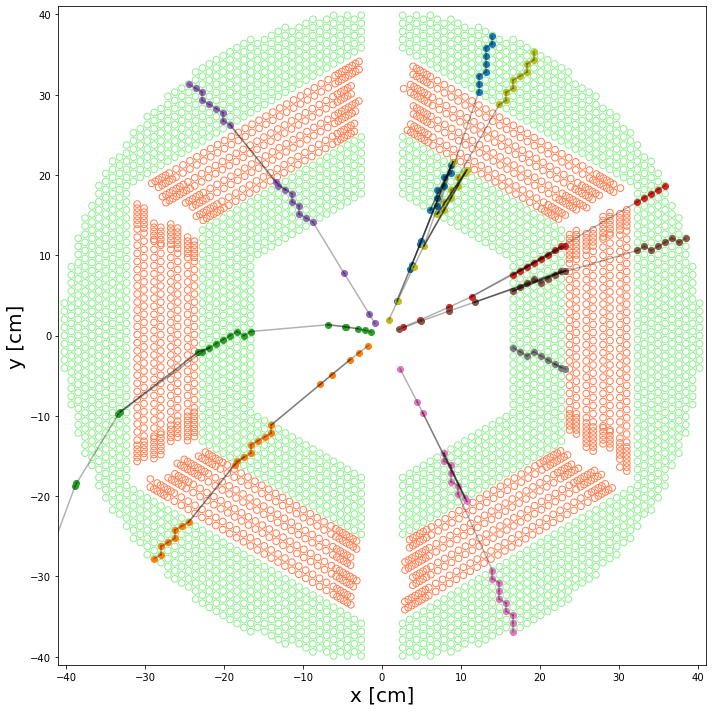

In [41]:
# Old: Plotting true_edges
plt.close('all')
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)

p_ids = np.unique(hits.particle_id.values)
det = pd.read_csv("../src/stt.csv")
skw = det.query('skewed==0')
nkw = det.query('skewed==1') # one look for +ve/-ve polarity

# detector layout
ax.scatter(skw.x.values, skw.y.values, s=44, facecolors='none', edgecolors='lightgreen')
ax.scatter(nkw.x.values, nkw.y.values, s=44, facecolors='none', edgecolors='coral')

# particle tracks
for pid in sel_pids:
    idx = hits.particle_id == pid
    ax.scatter(hits[idx].x.values, hits[idx].y.values, label='particle_id: %d' %pid)
    
# true edges
for iedge in range(true_edges.shape[1]):
    pt1 = hits.iloc[true_edges[0][iedge]]
    pt2 = hits.iloc[true_edges[1][iedge]]
    ax.plot([pt1.x, pt2.x], [pt1.y, pt2.y], color='k', alpha=0.3, lw=1.5)

# plotting params
ax.set_xlabel('x [cm]', fontsize=20)
ax.set_ylabel('y [cm]', fontsize=20)
# ax.set_title('Event ID # %d' % event_id)
ax.set_xlim(-41, 41)
ax.set_ylim(-41, 41)
ax.grid(False)
# ax.legend(fontsize=11, loc='best')
fig.tight_layout()
# fig.savefig("true_edges.pdf")

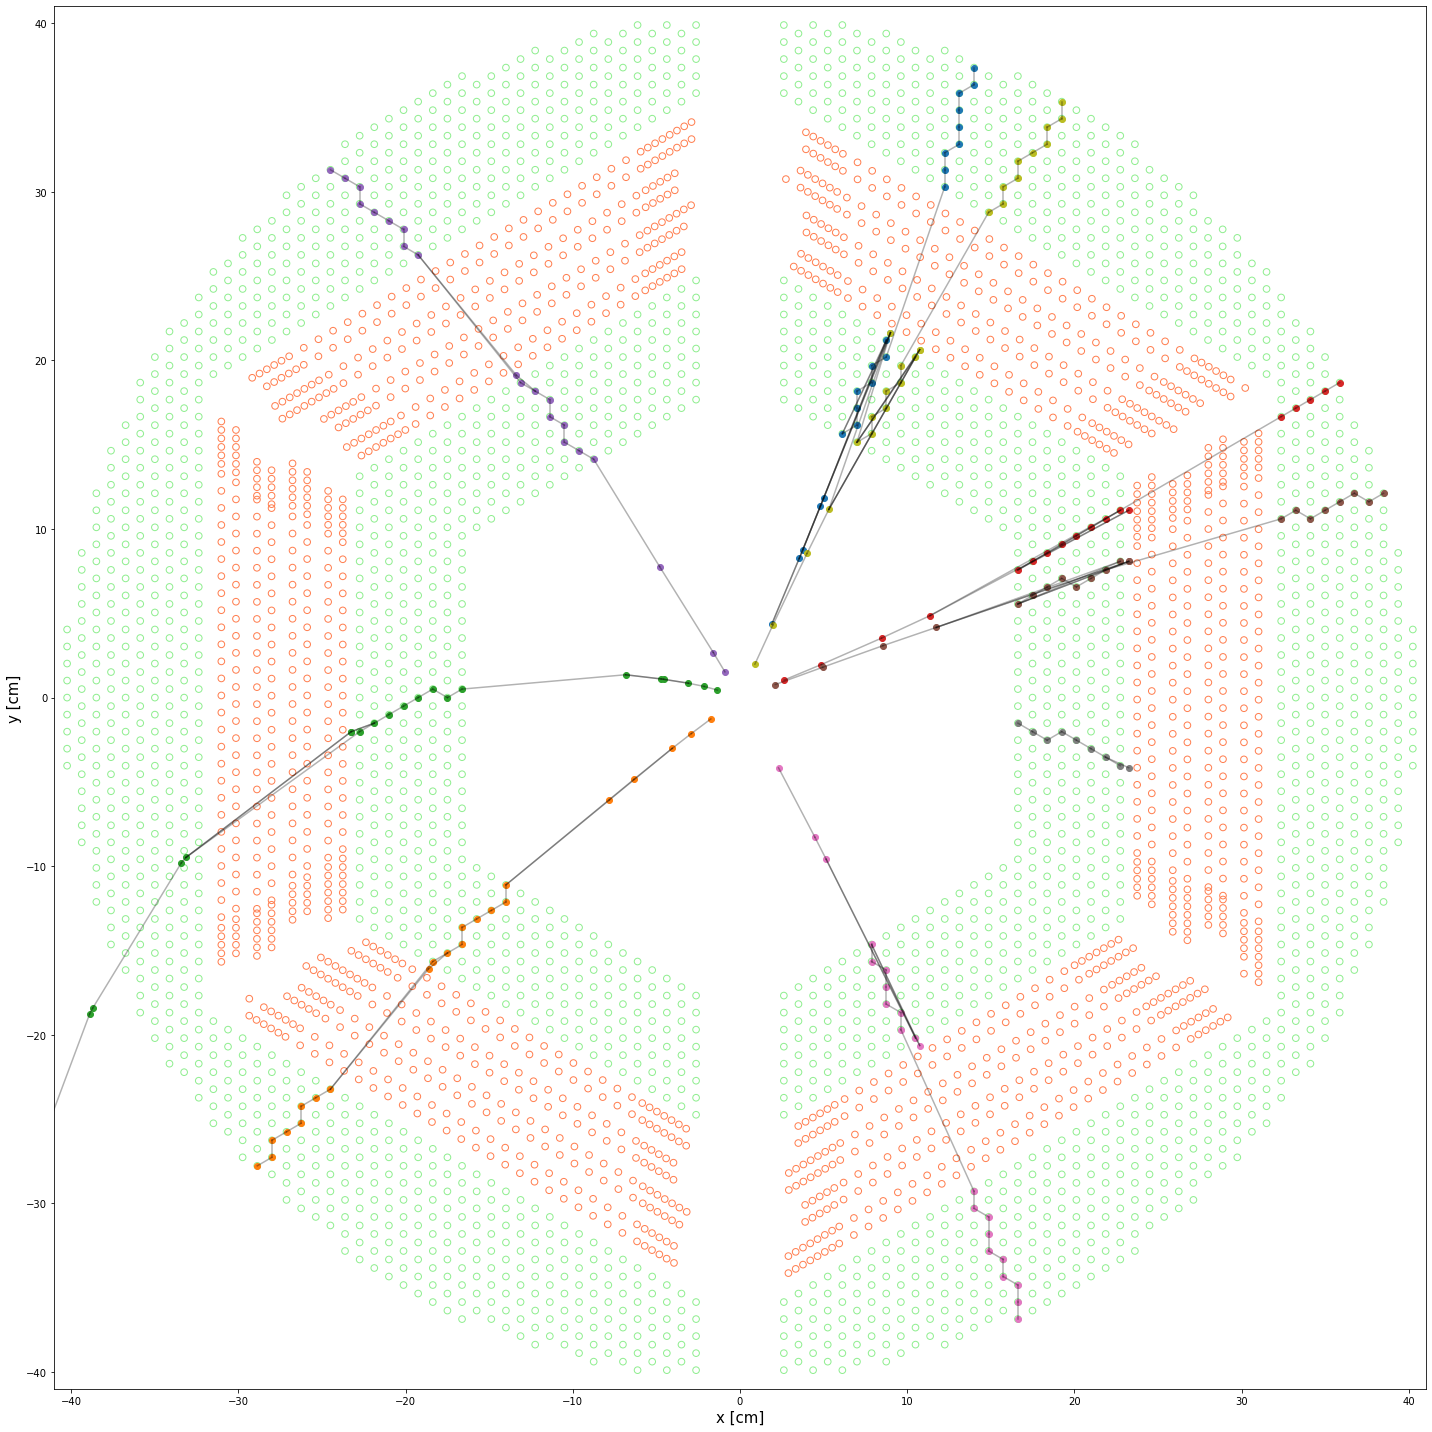

In [42]:
# New: Plotting true_edges
fig, ax = detector_layout(figsize=(20,20))

# particle tracks
for pid in sel_pids:
    idx = hits.particle_id == pid
    ax.scatter(hits[idx].x.values, hits[idx].y.values, label='particle_id: %d' %pid)
    
# true edges
for iedge in range(true_edges.shape[1]):
    pt1 = hits.iloc[true_edges[0][iedge]]
    pt2 = hits.iloc[true_edges[1][iedge]]
    ax.plot([pt1.x, pt2.x], [pt1.y, pt2.y], color='k', alpha=0.3, lw=1.5)

# axis params
# ax.legend(fontsize=12, loc='best')
fig.tight_layout()
fig.savefig("true_edges.pdf")